In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model="text-embedding-3-large")

vectorstore = Chroma(       
    embedding_function=embedding_function,
    collection_name="income_tax_collection",
    persist_directory="./income_tax_collection"
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph


class AgentState(TypedDict):
    query: str
    answer: str
    context: list
    
    
graph_builder = StateGraph(AgentState)
    

In [4]:
def retrieve(state: AgentState) :
    query = state["query"]
    docs = retriever.invoke(query)
    return {"context": docs}

In [5]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o")

In [6]:
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")
generate_llm = ChatOpenAI(model="gpt-4o", max_completion_tokens=100)

def generate(state:AgentState) :
    context = state["context"]
    query = state["query"]
    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    response = rag_chain.invoke({"context": context, "question": query})
    return {"answer": response}


In [7]:
# 문서 관련성 측정 노드 (상태에 _next를 넣어 다음 노드로 연결)

from langsmith import Client
from typing import Literal

client = Client()
doc_relevance_prompt = client.pull_prompt("langchain-ai/rag-document-relevance")

def check_doc_relevance(state: AgentState) -> Literal["relevant", "irrelevant"]:
    query = state["query"]
    context = state["context"]
    doc_relevance_chain = doc_relevance_prompt | llm
    response = doc_relevance_chain.invoke({"documents": context, "question": query})
    # 응답에서 Score 추출 (AIMessage면 .content, dict면 ["Score"])
    if response['Score'] == 1:
        return 'relevant'
    else:
        return 'irrelevant'


In [8]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

rewrite_prompt = PromptTemplate.from_template("""사용자의 질문을 보고, 웹 검색에 용이하게 사용자의 질문을 변경해주세요.
    질문 : {query}
    """
)

def rewrite(state:AgentState) :
    query = state["query"]
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()
    
    response = rewrite_chain.invoke({"query": query})
    return {"query": response}

tavily 공식지원으로 문법 변경됨


In [9]:
!uv pip install -qU langchain-tavily

In [10]:
from langchain_tavily import TavilySearch

tabily_search_tool = TavilySearch(
    max_results=3,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True
    )

def web_search(state:AgentState) :
    query = state["query"]
    results = tabily_search_tool.invoke(query)
    return {'context': results}

In [ ]:
graph_builder.add_node('retrieve', retrieve)
graph_builder.add_node('generate', generate)
#graph_builder.add_node('rewrite', rewrite)    공식문서에서는 추가해주라는 권장이 나왔지만 실제 테스트결과 굳이 필요가 없었다.
graph_builder.add_node('web_search', web_search)

In [ ]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges(
    'retrieve',
    check_doc_relevance,
    {
        'relevant': 'generate',
        'irrelevant': 'web_search'
    }
)
graph_builder.add_edge('web_search', 'generate')
#graph_builder.add_edge('rewrite', 'web_search')
graph_builder.add_edge('generate', END)



In [13]:
graph = graph_builder.compile()

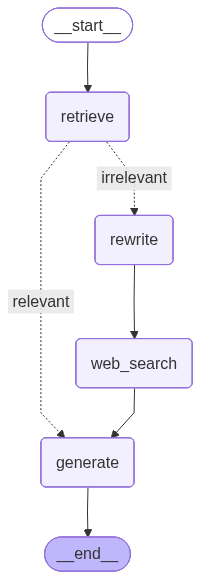

In [14]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
initial_state = {"query": '연봉 5천만원 거주자의 소득세는 얼마인가요?'}
graph.invoke(initial_state)

{'query': '연봉 5천만원 거주자의 소득세는 얼마인가요?',
 'answer': '연봉 5천만원 거주자의 소득세는 624만원입니다. 이는 과세표준이 5천만원을 초과하지 않으므로, 해당 금액에 대한 세율을 적용한 결과입니다.',
 'context': [Document(id='705d4c93-b456-4cf5-abf3-bd7de8317e36', metadata={'source': './documents/income_tax.txt'}, page_content='제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n\n종합소득\n┌───────────────┐\n│ 과세표준의 6개 구간 │\n├───────────────┤\n│ 1,400만원 이하        │ 84만원 + (1,400만원을 초과하는 금액의 15%)  │\n│ 1,400만원 초과        │ 84만원 + (5,000만원을 초과하는 금액의 24%)  │\n│ 8,800만원 이하        │ 624만원 + (5,000만원을 초과하는 금액의 24%)  │\n│ 8,800만원 초과        │ 1,536만원 + (8,800만원을 초과하는 금액의 35%)  │\n│ 1.5억원 초과          │ 4,046만원 + (1,500만원을 초과하는 금액의 38%)  │\n│ 3억원 초과            │ 6,460만원 + (3억원을 초과하는 금액의 40%)  │\n│ 5억원 초과            │ 14,760만원 + (5억원을 초과하는 금액의 42%)  │\n│ 10억원 초과           │ 38,406만원 + (10억원을 초과하는 금액의 45%)  │\n└───────────────┘\n\n② 거주자의 퇴직소득에 대한

In [16]:
initial_state = {"query": '테스트 케이스가 무엇인가요?'}
graph.invoke(initial_state)

{'query': '"테스트 케이스의 정의와 중요성에 대해 설명해주세요."',
 'answer': '테스트 케이스는 소프트웨어 기능을 검증하기 위해 특정 작업이나 조건 집합에서 예상 결과를 확인하는 시나리오입니다. 테스트 케이스는 소프트웨어 품질 보장과 결함 조기 발견에 중요하며, 효과적인 테스트 케이스는 소프트웨어의 신뢰성과 사용자 만족도를 높입니다. 이는 기능 누락을 방지하고 기획 의도에 맞게 구현되었는지를 확인하는 데 필수',
 'context': {'query': '테스트 케이스의 정의와 중요성에 대해 설명해주세요.',
  'follow_up_questions': None,
  'answer': 'A test case defines specific inputs and expected outcomes to verify software functionality. Its importance lies in ensuring software quality and identifying defects early. Effective test cases improve software reliability and user satisfaction.',
  'images': ['https://image.reportshop.co.kr/newprimg/961/960063-0002.gif',
   'https://velog.velcdn.com/images/psh666777/post/2138ae58-bfa7-4246-819d-2dc8c7d236a0/image.png',
   'https://image.reportshop.co.kr/thumb/961/960063-0007.gif',
   'https://cdn.inflearn.com/api/v1/og/questions/37184?lang=ja&updateKey=1591171552676',
   'https://image.reportshop.co.kr/newprimg/961/960063-0004.gif'],
  'results': [{'